In [1]:
from data.movie import Audio
from data.behavior import Suspense
import librosa
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import butter, sosfilt

In [2]:
audio = Audio()
sus = Suspense()

audio.raw.shape, sus.raw.shape

((22905856,), (193, 22))

In [3]:
def min_max_normalize(x): return (x - np.min(x)) / (np.max(x) - np.min(x))

def bandpass_filter(y, sr, low_hz, high_hz, order=4):
    # Design a 4th-order bandpass SOS filter
    sos = butter(order, [low_hz, high_hz],
                 btype='band', fs=sr, output='sos')
    # Apply it
    return sosfilt(sos, y)

In [4]:
sr = 48000  # Sample rate
hop = 512
frame = 2048

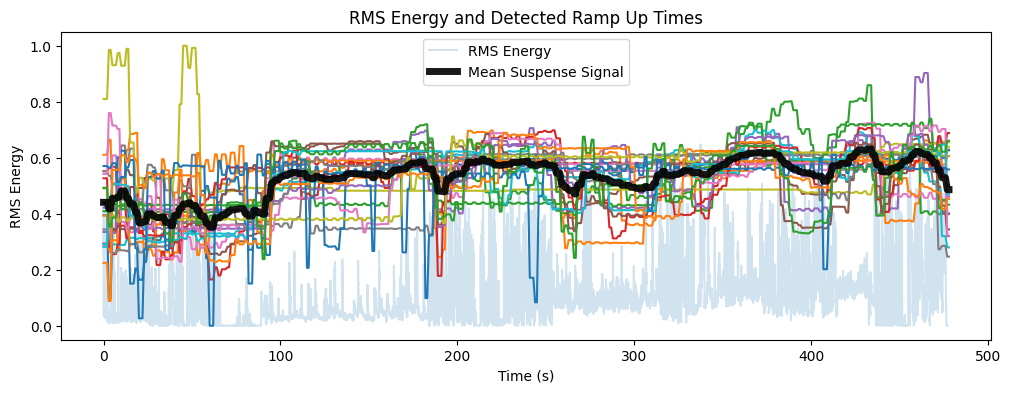

In [5]:
# Raw RMS energy with vocals + everything
rms = librosa.feature.rms(y=audio.raw, frame_length=2048, hop_length=512)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=512)

plt.figure(figsize=(12, 4))
plt.plot(times, rms, label='RMS Energy', alpha=0.2)
plt.plot(min_max_normalize(sus.rescale(1)))
plt.plot(min_max_normalize(sus.rescale(1)).mean(axis=1), 'k-', label='Mean Suspense Signal', alpha=0.9, linewidth=5)

plt.title('RMS Energy and Detected Ramp Up Times')
plt.xlabel('Time (s)')
plt.ylabel('RMS Energy')
plt.legend()
plt.show()

In [6]:
# load just the instrumentals
y_band, sr = librosa.load('accompaniment.wav', sr=None)

# pick a band that captures “tension” instruments — e.g. 200–2000 Hz
# bandpass_filter(y, sr, low_hz=200, high_hz=2000)

# short-time energy (RMS) on that band
rms = librosa.feature.rms(y=y_band, frame_length=frame, hop_length=hop)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)

# convert to dB
rms_db = librosa.power_to_db(rms**2, ref=np.max)

# smooth with a moving average (e.g. 1 second window)
win = int(1.0 * sr / hop)            # frames in 1 s
rms_smooth = np.convolve(rms_db, np.ones(win)/win, mode='same')

contrast = librosa.feature.spectral_contrast(y=y_band,sr=sr,n_bands=6,hop_length=hop)
# take the mean contrast across bands
contrast_mean = contrast.mean(axis=0)
contrast_smooth = np.convolve(contrast_mean, np.ones(win)/win, mode='same')

In [16]:
win

86

In [17]:
times

array([0.00000000e+00, 1.16099773e-02, 2.32199546e-02, ...,
       4.77181678e+02, 4.77193288e+02, 4.77204898e+02], shape=(41104,))

In [15]:
np.diff(times)

array([0.01160998, 0.01160998, 0.01160998, ..., 0.01160998, 0.01160998,
       0.01160998], shape=(41103,))

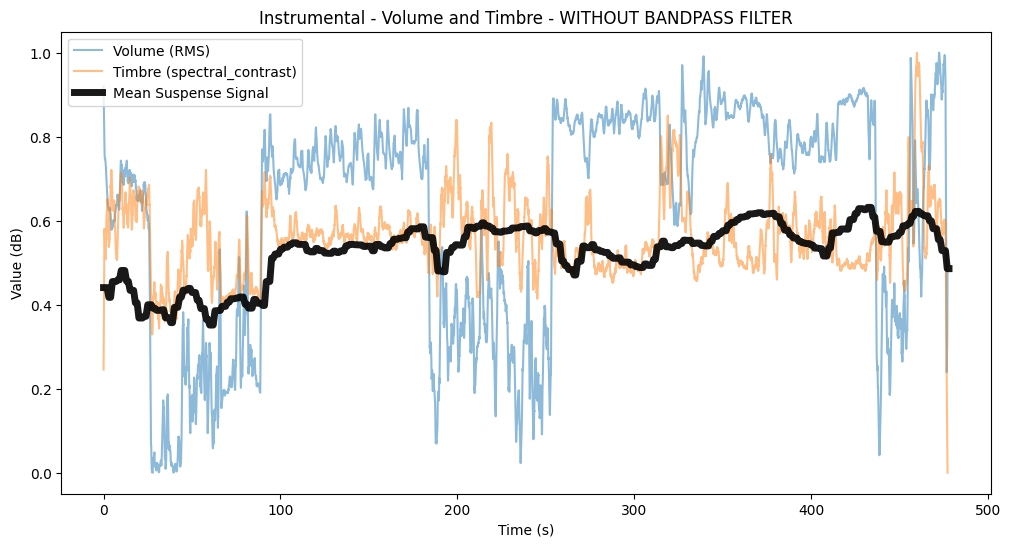

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(times, min_max_normalize(rms_smooth), label='Volume (RMS)', alpha=0.5)
plt.plot(times, min_max_normalize(contrast_smooth), label='Timbre (spectral_contrast)', alpha=0.5)
plt.plot( min_max_normalize(sus.rescale(1)).mean(axis=1), 'k-', label='Mean Suspense Signal', alpha=0.9, linewidth=5)

plt.title('Instrumental - Volume and Timbre - WITHOUT BANDPASS FILTER')
plt.xlabel('Time (s)')
plt.ylabel('Value (dB)')
plt.legend()
plt.show()

In [8]:
# load just the instrumentals
y_band, sr = librosa.load('accompaniment.wav', sr=None)

# pick a band that captures “tension” instruments — e.g. 200–2000 Hz
y_band = bandpass_filter(y_band, sr, low_hz=200, high_hz=2000)

# short-time energy (RMS) on that band
rms = librosa.feature.rms(y=y_band, frame_length=frame, hop_length=hop)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)

# convert to dB
rms_db = librosa.power_to_db(rms**2, ref=np.max)

# smooth with a moving average (e.g. 1 second window)
win = int(1.0 * sr / hop)            # frames in 1 s
rms_smooth = np.convolve(rms_db, np.ones(win)/win, mode='same')

contrast = librosa.feature.spectral_contrast(y=y_band,sr=sr,n_bands=6,hop_length=hop)
# take the mean contrast across bands
contrast_mean = contrast.mean(axis=0)
contrast_smooth = np.convolve(contrast_mean, np.ones(win)/win, mode='same')

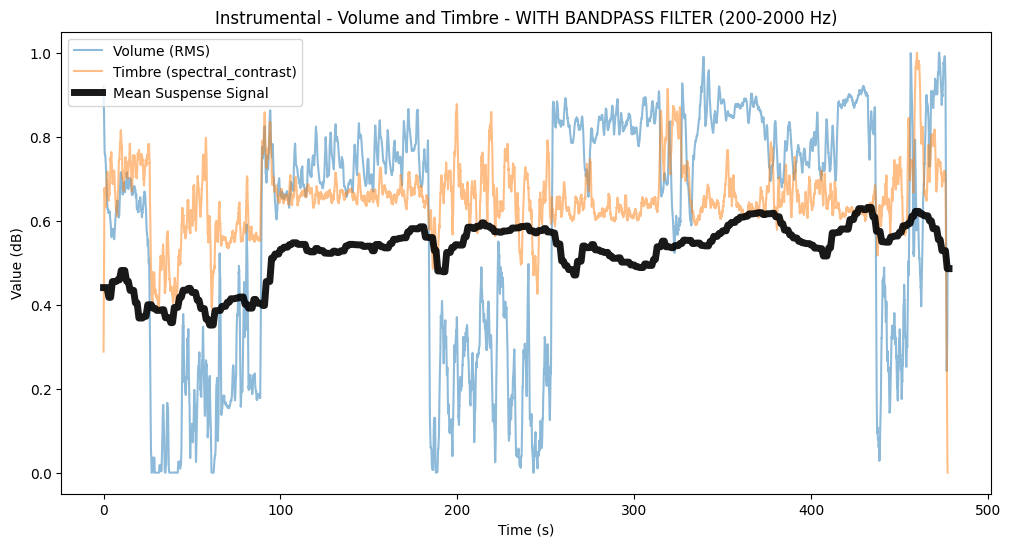

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(times, min_max_normalize(rms_smooth), label='Volume (RMS)', alpha=0.5)
plt.plot(times, min_max_normalize(contrast_smooth), label='Timbre (spectral_contrast)', alpha=0.5)
plt.plot( min_max_normalize(sus.rescale(1)).mean(axis=1), 'k-', label='Mean Suspense Signal', alpha=0.9, linewidth=5)

plt.title('Instrumental - Volume and Timbre - WITH BANDPASS FILTER (200-2000 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Value (dB)')
plt.legend()
plt.show()